In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

In [7]:
class Dataset:
    """
    Prepare the dataset into training, validation, and test sets.
    """
    def __init__(self, random_state = 123):
        self.data = pd.read_csv("data/cleaned_data.csv")
        y_df = self.data["VOTED"].map({"voted": 0, "not_voted": 1}).to_numpy()
        X_df = self.data.drop(columns=["VOTED"])

        categorical_feature = ["SEX", "RACE", "EDUC", "EMPSTAT", "NATIVITY", "REGION",
                               "METRO", "MARST", "DIFFMOB"]
        numerical_feature = ["AGE", "NCHILD", "INCOME_PER_PERSON"]

        ## training set 70%, validation set 10%, test set 20%
        #added stratify in addition to neural networks code
        train_x, rest_x, self.train_y, rest_y = train_test_split(
            X_df, y_df, test_size=0.3, random_state=random_state, stratify=y_df)
        val_x, test_x, self.val_y, self.test_y = train_test_split(
            rest_x, rest_y, test_size=(2/3), random_state=random_state, stratify=rest_y)
        
        self.ohe = OneHotEncoder(sparse_output=False)
        self.scaler = StandardScaler()

        train_x_categorical = self.ohe.fit_transform(train_x[categorical_feature])
        train_x_numerical = self.scaler.fit_transform(train_x[numerical_feature])
        val_x_categorical = self.ohe.transform(val_x[categorical_feature])
        val_x_numerical = self.scaler.transform(val_x[numerical_feature])
        test_x_categorical = self.ohe.transform(test_x[categorical_feature])
        test_x_numerical = self.scaler.transform(test_x[numerical_feature])

        self.train_x = np.concatenate([train_x_categorical, train_x_numerical], axis=1)
        self.val_x = np.concatenate([val_x_categorical, val_x_numerical], axis=1)
        self.test_x = np.concatenate([test_x_categorical, test_x_numerical], axis=1)

        categorical_feature_name = self.ohe.get_feature_names_out(categorical_feature)
        numerical_feature_name = self.scaler.get_feature_names_out(numerical_feature)
        self.feature_order = np.concatenate([categorical_feature_name, numerical_feature_name])

In [8]:
#baseline model

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Load prepared data (Stage 2 output)
ds = Dataset(random_state=123)

# Sanity check:class balance? 
print("Class balance (train):", np.bincount(ds.train_y))
print("Proportion non-voted:", ds.train_y.mean().round(3))
print()

# Build the baseline forest
rf = RandomForestClassifier(
    n_estimators=500,          # safe plateau
    max_features="sqrt",       # the sqrt(p) rule for classification
    max_depth=None,            # grow deep; averaging controls variance
    min_samples_leaf=1,        # default
    bootstrap=True,            # enables OOB
    oob_score=True,            # free generalization estimate
    class_weight="balanced",   # guard against imbalance
    n_jobs=-1,                 # parallel (trees are independent)
    random_state=123,
)

# Train
rf.fit(ds.train_x, ds.train_y)

# Evaluate on the VALIDATION set
val_pred  = rf.predict(ds.val_x)
val_proba = rf.predict_proba(ds.val_x)[:, 1]   # P(non-voted)

print(f"  Accuracy : {accuracy_score(ds.val_y, val_pred):.4f}")
print(f"  Precision: {precision_score(ds.val_y, val_pred):.4f}")
print(f"  Recall   : {recall_score(ds.val_y, val_pred):.4f}")
print(f"  F1       : {f1_score(ds.val_y, val_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(ds.val_y, val_proba):.4f}")
print("Confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(ds.val_y, val_pred))
print(classification_report(ds.val_y, val_pred, target_names=["voted", "not_voted"]))

Class balance (train): [33499 10129]
Proportion non-voted: 0.232

  Accuracy : 0.7361
  Precision: 0.4174
  Recall   : 0.3455
  F1       : 0.3781
  ROC-AUC  : 0.6859
Confusion matrix [rows=actual, cols=predicted]:
[[4088  698]
 [ 947  500]]
              precision    recall  f1-score   support

       voted       0.81      0.85      0.83      4786
   not_voted       0.42      0.35      0.38      1447

    accuracy                           0.74      6233
   macro avg       0.61      0.60      0.61      6233
weighted avg       0.72      0.74      0.73      6233



In [9]:

mf_options = {"sqrt": "sqrt", "log2": "log2", "0.3": 0.3, "0.5": 0.5, "1.0": 1.0}
for label, mf in mf_options.items():
    m = RandomForestClassifier(n_estimators=300, max_features=mf,
            class_weight="balanced", n_jobs=-1, random_state=123)
    m.fit(ds.train_x, ds.train_y)
    auc = roc_auc_score(ds.val_y, m.predict_proba(ds.val_x)[:, 1])
    print(f"max_features={label:5s} -> val AUC {auc:.4f}")

max_features=sqrt  -> val AUC 0.6861
max_features=log2  -> val AUC 0.6839
max_features=0.3   -> val AUC 0.6887
max_features=0.5   -> val AUC 0.6920
max_features=1.0   -> val AUC 0.6900


In [10]:
#threshold tuning
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score

rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=123)
rf.fit(ds.train_x, ds.train_y)
proba = rf.predict_proba(ds.val_x)[:, 1]   # P(non-voter)

print(f"{'thresh':>7} {'recall':>7} {'prec':>7} {'F1':>7}")
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred = (proba >= t).astype(int)
    r = recall_score(ds.val_y, pred)
    p = precision_score(ds.val_y, pred, zero_division=0)
    f = f1_score(ds.val_y, pred)
    print(f"{t:>7.2f} {r:>7.3f} {p:>7.3f} {f:>7.3f}")

 thresh  recall    prec      F1
   0.30   0.561   0.352   0.433
   0.35   0.510   0.370   0.429
   0.40   0.447   0.379   0.410
   0.45   0.395   0.391   0.393
   0.50   0.346   0.417   0.379
   0.55   0.292   0.441   0.352
   0.60   0.216   0.431   0.287


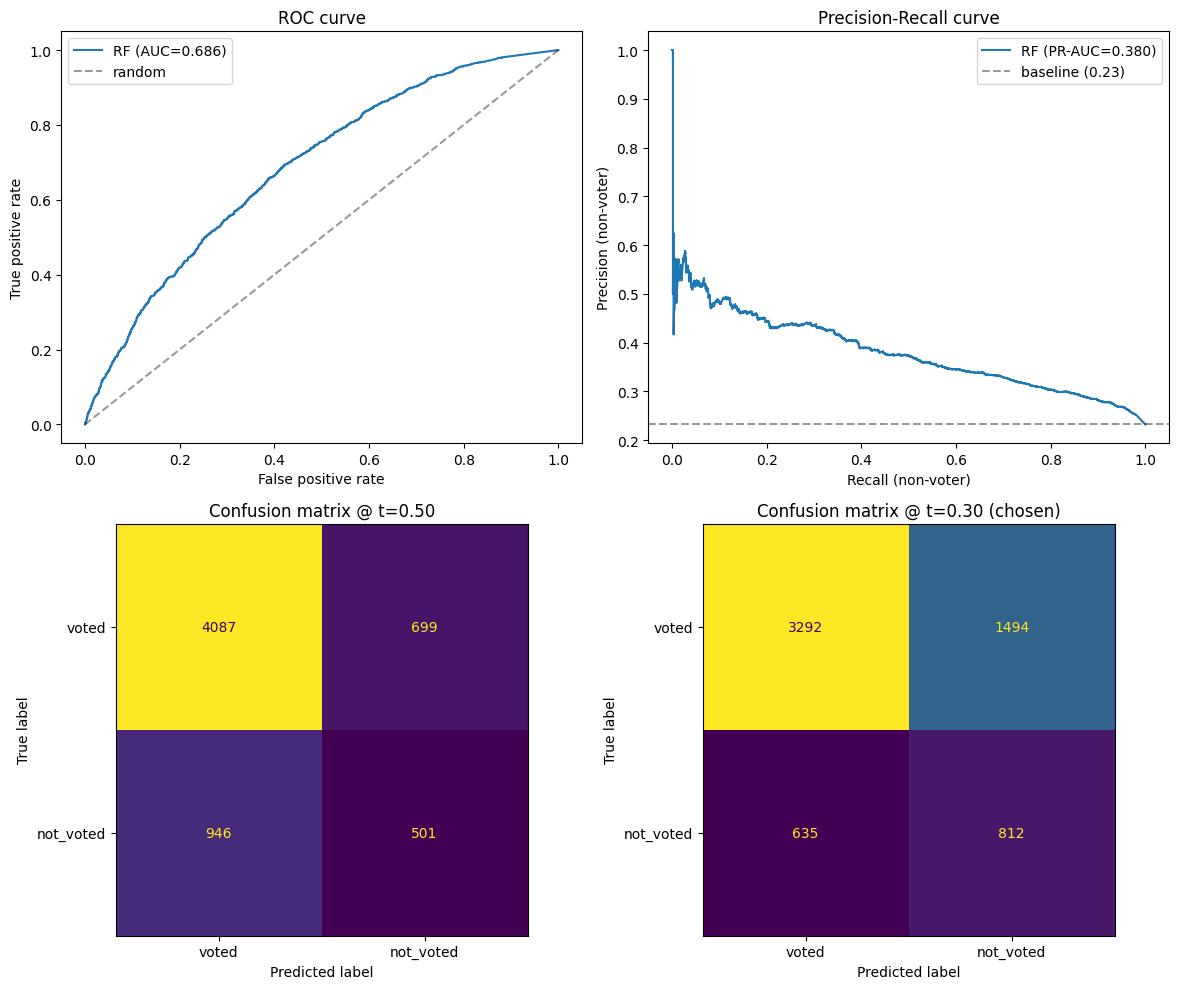

In [11]:

# Refit final config, get P(non-voter) on validation
rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=123)
rf.fit(ds.train_x, ds.train_y)
proba = rf.predict_proba(ds.val_x)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ROC curve
fpr, tpr, _ = roc_curve(ds.val_y, proba)
auc = roc_auc_score(ds.val_y, proba)
axes[0,0].plot(fpr, tpr, label=f"RF (AUC={auc:.3f})")
axes[0,0].plot([0,1], [0,1], "k--", alpha=0.4, label="random")
axes[0,0].set_xlabel("False positive rate"); axes[0,0].set_ylabel("True positive rate")
axes[0,0].set_title("ROC curve"); axes[0,0].legend()

# PR curve (non-voter = positive; the honest one for imbalance)
prec, rec, _ = precision_recall_curve(ds.val_y, proba)
ap = average_precision_score(ds.val_y, proba)
baseline = ds.val_y.mean()  # prevalence of non-voters
axes[0,1].plot(rec, prec, label=f"RF (PR-AUC={ap:.3f})")
axes[0,1].axhline(baseline, ls="--", color="k", alpha=0.4,
                  label=f"baseline ({baseline:.2f})")
axes[0,1].set_xlabel("Recall (non-voter)"); axes[0,1].set_ylabel("Precision (non-voter)")
axes[0,1].set_title("Precision-Recall curve"); axes[0,1].legend()

# Confusion matrix at t=0.50
cm50 = confusion_matrix(ds.val_y, (proba >= 0.50).astype(int))
ConfusionMatrixDisplay(cm50, display_labels=["voted","not_voted"]).plot(
    ax=axes[1,0], colorbar=False)
axes[1,0].set_title("Confusion matrix @ t=0.50")

# Confusion matrix at t=0.30 (chosen)
cm30 = confusion_matrix(ds.val_y, (proba >= 0.30).astype(int))
ConfusionMatrixDisplay(cm30, display_labels=["voted","not_voted"]).plot(
    ax=axes[1,1], colorbar=False)
axes[1,1].set_title("Confusion matrix @ t=0.30 (chosen)")

plt.tight_layout()
plt.show()

/Users/srinathraopathangae/coding_courses/machinelearning/project-voting_demographics_project/rf_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/srinathraopathangae/coding_courses/machinelearning/project-voting_demographics_project/rf_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/srinathraopathangae/coding_courses/machinelearning/project-voting_demographics_project/rf_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with

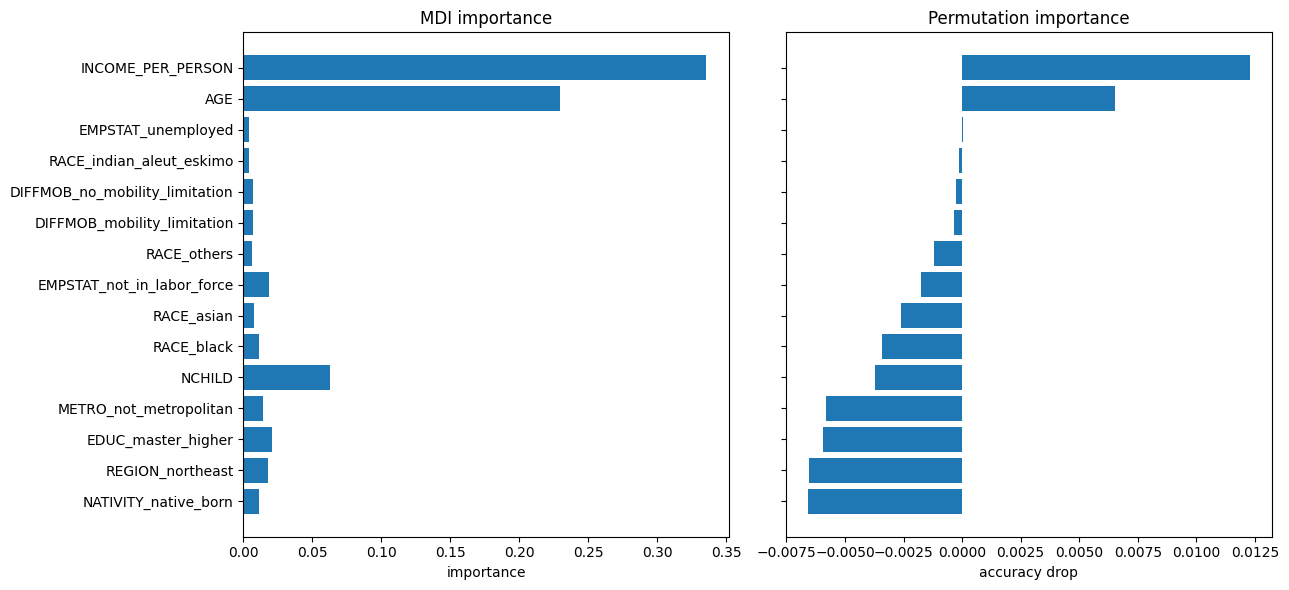

Top 10 features (permutation):
  INCOME_PER_PERSON              0.0123
  AGE                            0.0065
  EMPSTAT_unemployed             0.0000
  RACE_indian_aleut_eskimo       -0.0001
  DIFFMOB_no_mobility_limitation -0.0002
  DIFFMOB_mobility_limitation    -0.0003
  RACE_others                    -0.0012
  EMPSTAT_not_in_labor_force     -0.0017
  RACE_asian                     -0.0026
  RACE_black                     -0.0034


In [12]:
#feature importance

rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=123)
rf.fit(ds.train_x, ds.train_y)

# MDI (free, from training)
mdi = rf.feature_importances_

# Permutation (on validation, honest, no cardinality bias)
perm = permutation_importance(rf, ds.val_x, ds.val_y,
        n_repeats=10, random_state=123, n_jobs=-1)
pim = perm.importances_mean

# Top 15
order = pim.argsort()[::-1][:15]
names = ds.feature_order[order]

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
y = np.arange(len(order))[::-1]
ax[0].barh(y, mdi[order]);  ax[0].set_yticks(y); ax[0].set_yticklabels(names)
ax[0].set_title("MDI importance"); ax[0].set_xlabel("importance")
ax[1].barh(y, pim[order]);  ax[1].set_yticks(y); ax[1].set_yticklabels([])
ax[1].set_title("Permutation importance"); ax[1].set_xlabel("accuracy drop")
plt.tight_layout(); plt.show()

print("Top 10 features (permutation):")
for i in order[:10]:
    print(f"  {ds.feature_order[i]:30s} {pim[i]:.4f}")

In [13]:
#combine train and val data and then test on test data

final_x = np.concatenate([ds.train_x, ds.val_x], axis=0)
final_y = np.concatenate([ds.train_y, ds.val_y], axis=0)

final_rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=123)
final_rf.fit(final_x, final_y)

# Evaluate on the test set
proba = final_rf.predict_proba(ds.test_x)[:, 1]   # P(non-voter)
pred  = (proba >= 0.30).astype(int)               # chosen threshold

print(f"  ROC-AUC            : {roc_auc_score(ds.test_y, proba):.4f}")
print(f"  PR-AUC (non-voter) : {average_precision_score(ds.test_y, proba):.4f}")
print(f"  Recall (non-voter) : {recall_score(ds.test_y, pred):.4f}")
print(f"  Precision          : {precision_score(ds.test_y, pred):.4f}")
print(f"  F1 (non-voter)     : {f1_score(ds.test_y, pred):.4f}")
print("Confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(ds.test_y, pred))

  ROC-AUC            : 0.6829
  PR-AUC (non-voter) : 0.3717
  Recall (non-voter) : 0.5536
  Precision          : 0.3532
  F1 (non-voter)     : 0.4312
Confusion matrix [rows=actual, cols=predicted]:
[[6638 2934]
 [1292 1602]]


In [15]:
print("Total input features:", ds.train_x.shape)
print(ds.feature_order)

Total input features: (43628, 29)
['SEX_female' 'SEX_male' 'RACE_asian' 'RACE_black'
 'RACE_indian_aleut_eskimo' 'RACE_others' 'RACE_white' 'EDUC_college_grad'
 'EDUC_hs_grad' 'EDUC_master_higher' 'EMPSTAT_employed'
 'EMPSTAT_not_in_labor_force' 'EMPSTAT_retired' 'EMPSTAT_unemployed'
 'NATIVITY_foreign_born' 'NATIVITY_native_born' 'REGION_midwest'
 'REGION_northeast' 'REGION_south' 'REGION_west' 'METRO_metropolitan'
 'METRO_not_metropolitan' 'MARST_has_spouse' 'MARST_no_spouse'
 'DIFFMOB_mobility_limitation' 'DIFFMOB_no_mobility_limitation' 'AGE'
 'NCHILD' 'INCOME_PER_PERSON']


n_estimators=   50 -> val AUC 0.6803
n_estimators=  100 -> val AUC 0.6829
n_estimators=  200 -> val AUC 0.6853
n_estimators=  300 -> val AUC 0.6861
n_estimators=  500 -> val AUC 0.6859
n_estimators=  800 -> val AUC 0.6859
n_estimators= 1000 -> val AUC 0.6859


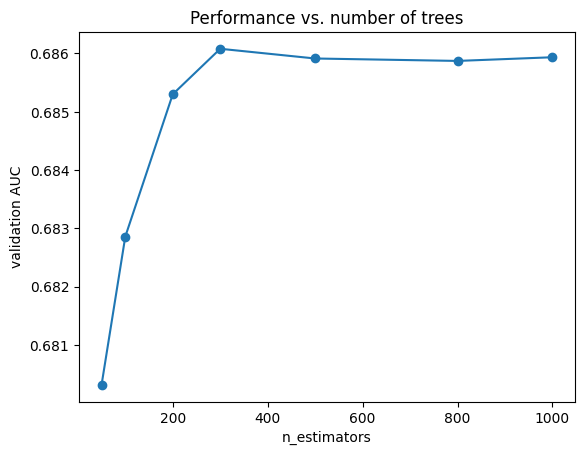

In [16]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

n_values = [50, 100, 200, 300, 500, 800, 1000]
aucs = []
for n in n_values:
    m = RandomForestClassifier(n_estimators=n, max_features="sqrt",
            class_weight="balanced", n_jobs=-1, random_state=123)
    m.fit(ds.train_x, ds.train_y)
    aucs.append(roc_auc_score(ds.val_y, m.predict_proba(ds.val_x)[:, 1]))
    print(f"n_estimators={n:5d} -> val AUC {aucs[-1]:.4f}")

plt.plot(n_values, aucs, marker="o")
plt.xlabel("n_estimators"); plt.ylabel("validation AUC")
plt.title("Performance vs. number of trees"); plt.show()